<a href="https://colab.research.google.com/github/anujyad810-dot/Cloud-Service-Resource-Anomaly/blob/main/Cloud_Service_Resource_Anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
import pandas as pd
import io

# STEP 1: Upload Data File
print("🟢 Pehle DATA file select karein (e.g., 'test' folder ke andar wali machine-1-1.txt)")
uploaded_data = files.upload()
data_filename = list(uploaded_data.keys())[0]

# STEP 2: Upload Label File
print("\n🟢 Ab LABEL file select karein (e.g., 'test_label' folder ke andar wali machine-1-1.txt)")
uploaded_label = files.upload()
label_filename = list(uploaded_label.keys())[0]

print("\nProcessing your files...")

# Files ko read karna
df_features = pd.read_csv(io.BytesIO(uploaded_data[data_filename]), header=None)
df_labels = pd.read_csv(io.BytesIO(uploaded_label[label_filename]), header=None)

# Sirf first 5 metrics extract karna aur rename karna
df = df_features.iloc[:, 0:5].copy()
df.columns = ['cpu_usage', 'memory_usage', 'request_rate', 'latency', 'network_throughput']

# Labels merge karna
df['is_anomaly'] = df_labels.iloc[:, 0]

# Missing values hatana
df = df.dropna()

print("\n✅ Dataset Bilkul Ready Hai!")
print(f"Total Rows: {df.shape[0]}, Columns: {df.shape[1]}")
display(df.head())

🟢 Pehle DATA file select karein (e.g., 'test' folder ke andar wali machine-1-1.txt)


Saving machine-1-1.txt to machine-1-1.txt

🟢 Ab LABEL file select karein (e.g., 'test_label' folder ke andar wali machine-1-1.txt)


Saving machine-1-1.txt to machine-1-1 (1).txt

Processing your files...

✅ Dataset Bilkul Ready Hai!
Total Rows: 28479, Columns: 6


,cpu_usage,memory_usage,request_rate,latency,network_throughput,is_anomaly
0,0.075269,0.065678,0.070234,0.074332,0.0,0
1,0.086022,0.080508,0.075808,0.076655,0.0,0
2,0.075269,0.064619,0.071349,0.074332,0.0,0
3,0.086022,0.048729,0.063545,0.070848,0.0,0
4,0.086022,0.051907,0.062430,0.070848,0.0,0


🔍 1. DATA QUALITY CHECKS
------------------------------
Missing Values:
cpu_usage             0
memory_usage          0
request_rate          0
latency               0
network_throughput    0
is_anomaly            0
dtype: int64

Duplicate Rows: 807

Class Balance (Target 'is_anomaly'):
is_anomaly
0    90.540398
1     9.459602
Name: proportion, dtype: float64



/tmp/ipykernel_433/1688605321.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_anomaly', palette='Set2')


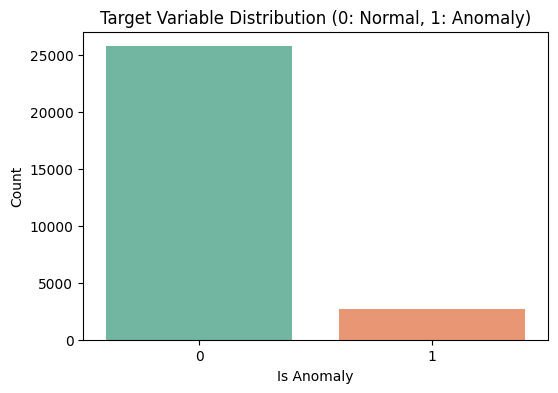

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your dataset is loaded into 'df'
print("🔍 1. DATA QUALITY CHECKS")
print("-" * 30)
print(f"Missing Values:\n{df.isnull().sum()}\n")
print(f"Duplicate Rows: {df.duplicated().sum()}\n")
print(f"Class Balance (Target 'is_anomaly'):\n{df['is_anomaly'].value_counts(normalize=True) * 100}\n")

# Visualizing Class Imbalance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_anomaly', palette='Set2')
plt.title('Target Variable Distribution (0: Normal, 1: Anomaly)')
plt.xlabel('Is Anomaly')
plt.ylabel('Count')
plt.show()

📊 2. FEATURE DISTRIBUTIONS
------------------------------


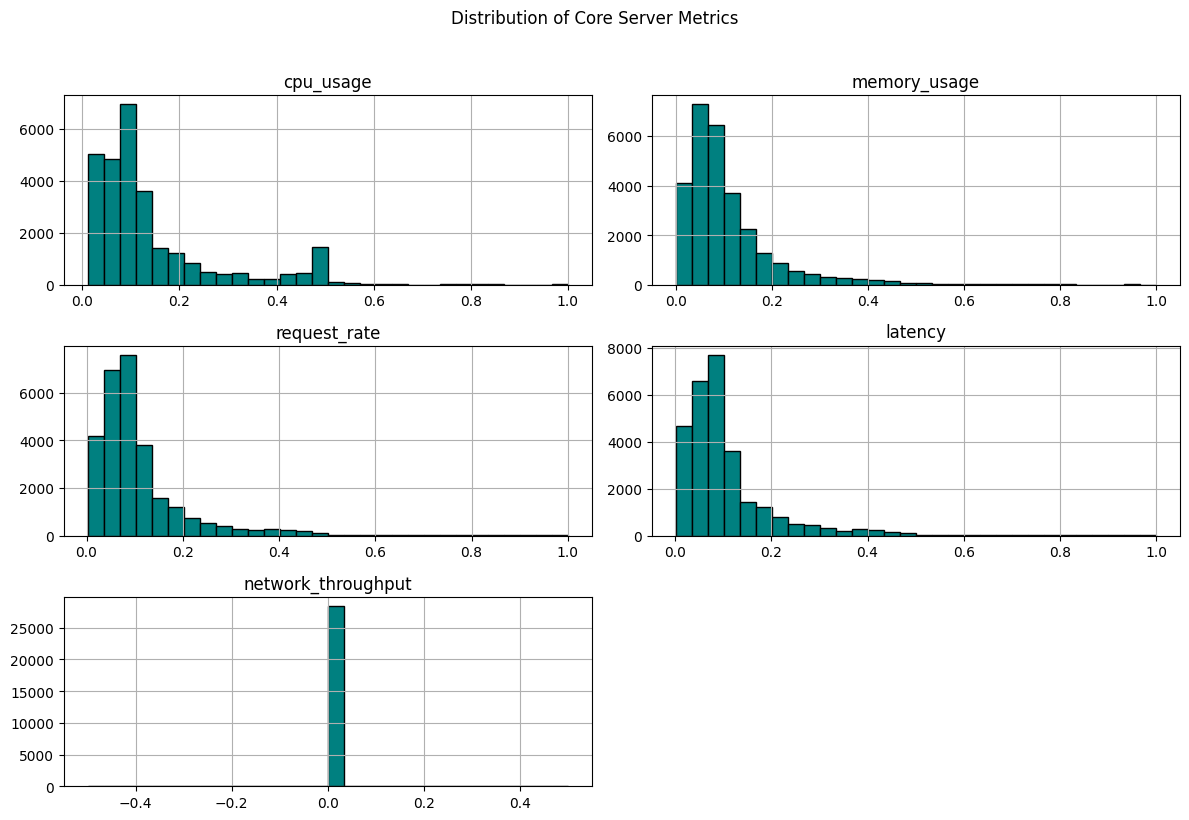

In [6]:
print("📊 2. FEATURE DISTRIBUTIONS")
print("-" * 30)
base_features = ['cpu_usage', 'memory_usage', 'request_rate', 'latency', 'network_throughput']

df[base_features].hist(bins=30, figsize=(12, 8), color='teal', edgecolor='black')
plt.suptitle('Distribution of Core Server Metrics', y=1.02)
plt.tight_layout()
plt.show()

🔗 3. FEATURE RELATIONSHIPS (CORRELATION)
------------------------------


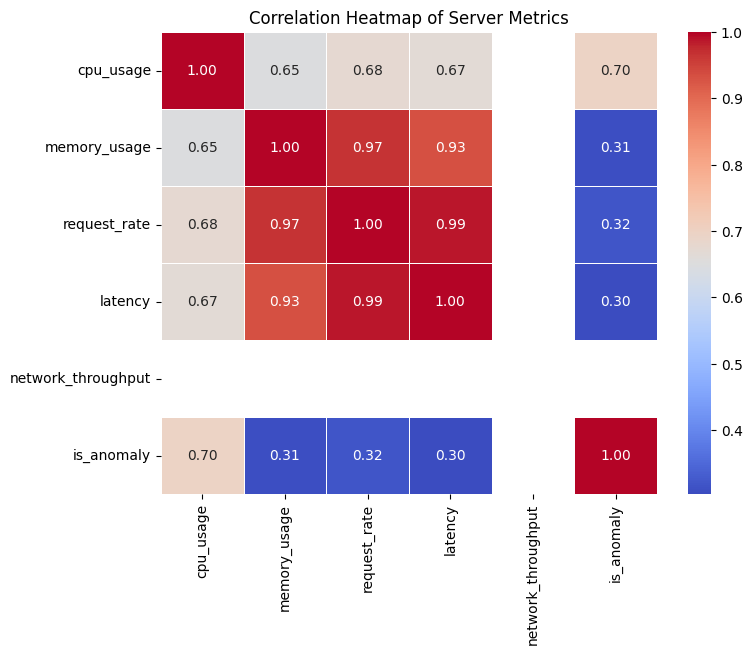

In [7]:
print("🔗 3. FEATURE RELATIONSHIPS (CORRELATION)")
print("-" * 30)
plt.figure(figsize=(8, 6))
correlation_matrix = df[base_features + ['is_anomaly']].corr()

# Using a heatmap to show correlations
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Server Metrics')
plt.show()

📈 4. OUTLIER INVESTIGATION BY CLASS
------------------------------


/tmp/ipykernel_433/15064640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_anomaly', y=feature, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_433/15064640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_anomaly', y=feature, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_433/15064640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_anomaly', y=feature, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_433/15064640.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated an

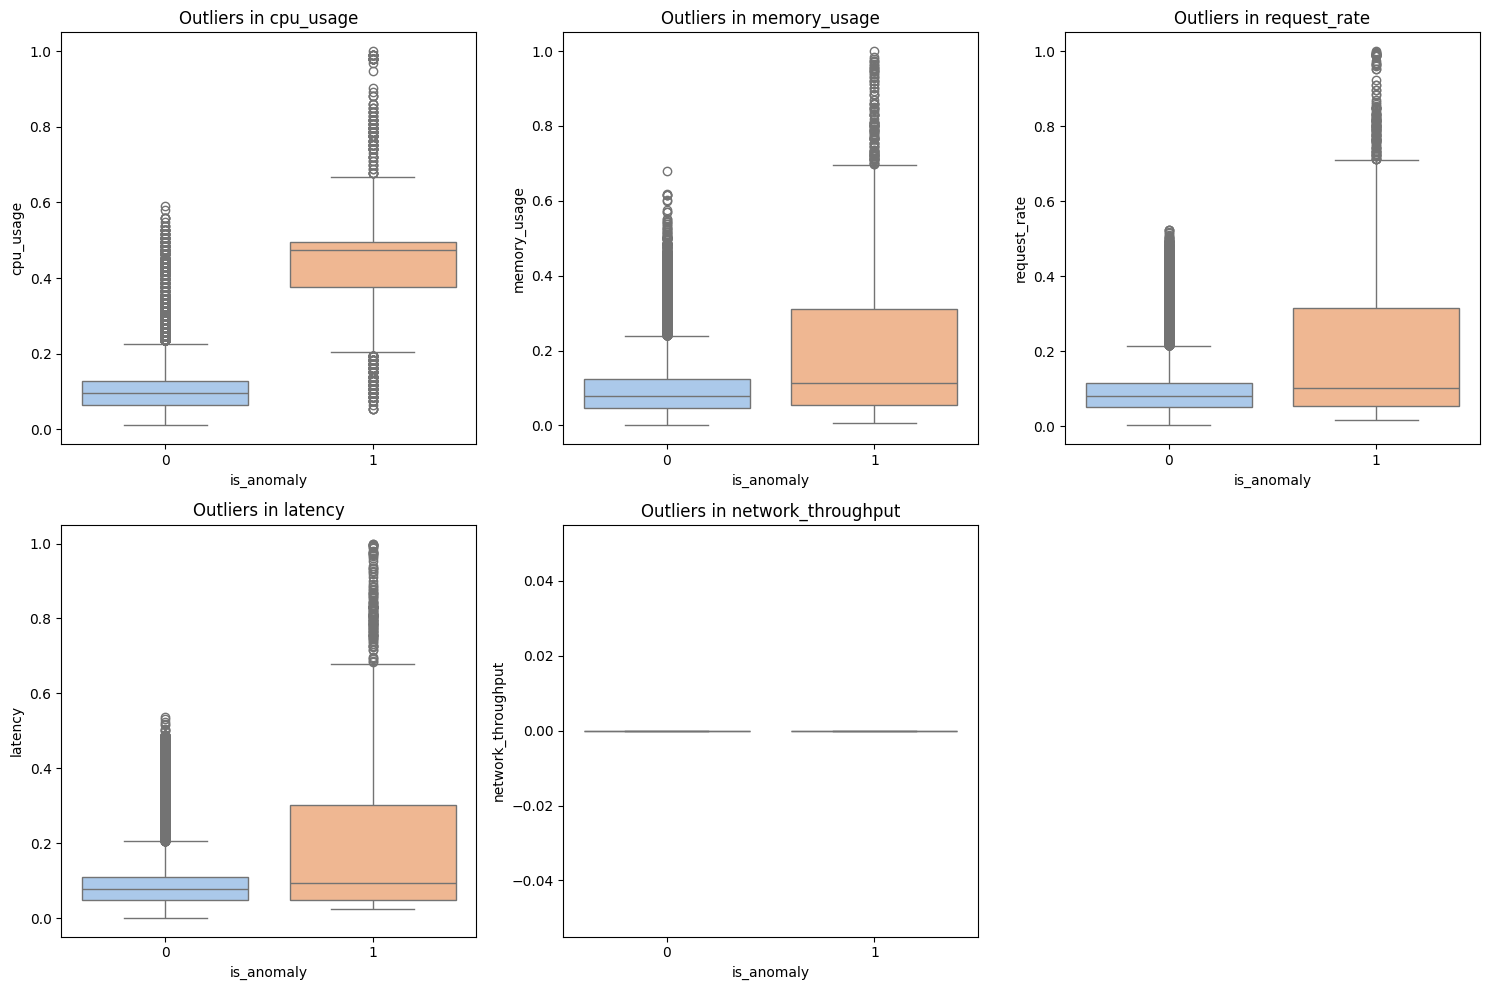

In [8]:
print("📈 4. OUTLIER INVESTIGATION BY CLASS")
print("-" * 30)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(base_features):
    sns.boxplot(x='is_anomaly', y=feature, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'Outliers in {feature}')

# Remove the empty 6th subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, precision_recall_curve, roc_auc_score, accuracy_score

print("⚙️ Preparing Classical ML Pipeline with Standardized Features...")

# 1. Feature Engineering (Exact 9 Features)
df_feat = df.copy()
df_feat['system_load'] = df_feat['cpu_usage'] * df_feat['memory_usage']
df_feat['latency_per_req'] = df_feat['latency'] / (df_feat['request_rate'] + 0.001)
df_feat['throughput_efficiency'] = df_feat['network_throughput'] / (df_feat['cpu_usage'] + 0.001)
df_feat['resource_stress'] = np.sqrt(df_feat['cpu_usage']**2 + df_feat['memory_usage']**2)

# Define exact column ordering
feature_cols = [
    'cpu_usage', 'memory_usage', 'request_rate', 'latency', 'network_throughput',
    'system_load', 'latency_per_req', 'throughput_efficiency', 'resource_stress'
]

X = df_feat[feature_cols]
y = df_feat['is_anomaly']

# 2. Train-Test Split & Robust Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Classical Decision Tree Tuning
param_grid = {
    'max_depth': [6, 8, 10, 12],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
best_dt_model = grid_search.best_estimator_

# 4. Optimal Threshold Calculation
probabilities = best_dt_model.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probabilities)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
best_f1 = f1_scores[best_idx]

y_pred_optimal = (probabilities >= best_threshold).astype(int)

# 5. Output Evaluation Metrics
print("\n" + "="*50)
print("🎯 CLASSICAL DECISION TREE EVALUATION REPORT")
print("="*50)
print(f"Optimal Decision Threshold : {best_threshold:.4f}")
print(f"Accuracy Score             : {accuracy_score(y_test, y_pred_optimal)*100:.2f}%")
print(f"Optimal F1-Score           : {best_f1:.4f}")
print(f"ROC-AUC Score              : {roc_auc_score(y_test, probabilities):.4f}")
print("-" * 50)
print(classification_report(y_test, y_pred_optimal, digits=4))

# 6. Save Fresh Artifacts
joblib.dump(best_dt_model, 'cloud_anomaly_model.pkl')
joblib.dump(scaler, 'cloud_scaler.pkl')
joblib.dump(best_threshold, 'best_threshold.pkl')

print("\n✅ New files saved! Please download 'cloud_anomaly_model.pkl', 'cloud_scaler.pkl', and 'best_threshold.pkl' to your local folder.")

⚙️ Preparing Classical ML Pipeline with Standardized Features...

🎯 CLASSICAL DECISION TREE EVALUATION REPORT
Optimal Decision Threshold : 0.5714
Accuracy Score             : 96.45%
Optimal F1-Score           : 0.7909
ROC-AUC Score              : 0.9238
--------------------------------------------------
              precision    recall  f1-score   support

           0     0.9702    0.9913    0.9806      5157
           1     0.8946    0.7087    0.7909       539

    accuracy                         0.9645      5696
   macro avg     0.9324    0.8500    0.8858      5696
weighted avg     0.9631    0.9645    0.9627      5696


✅ New files saved! Please download 'cloud_anomaly_model.pkl', 'cloud_scaler.pkl', and 'best_threshold.pkl' to your local folder.
